In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("epa_packaging_ml_ready_totals.csv")

# --- basic cleaning ---
df = df.dropna(subset=["generated_tons"])
df = df[df["generated_tons"] > 0].copy()

# fill missing flow values (safe)
for col in ["recycled_tons", "landfilled_tons", "combusted_tons"]:
    df[col] = df[col].fillna(0)

# recompute shares safely
df["recycling_rate"]   = df["recycled_tons"]   / df["generated_tons"]
df["landfill_share"]   = df["landfilled_tons"] / df["generated_tons"]
df["combustion_share"] = df["combusted_tons"]  / df["generated_tons"]

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=["recycling_rate", "landfill_share", "combustion_share"]).copy()

# sustainability score (0-100)
df["sustainability_score"] = (
    100 * df["recycling_rate"]
    - 60 * df["landfill_share"]
    - 20 * df["combustion_share"]
).clip(0, 100)

X_cols = [
    "generated_tons",
    "recycled_tons",
    "landfilled_tons",
    "combusted_tons",
    "recycling_rate",
    "landfill_share",
    "combustion_share"
]

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# --- Better class labels so each class has enough rows ---
# Rule:
# - score == 0  -> Harmful
# - positive scores -> split into 2 quantiles (Moderate vs Sustainable)

score = df["sustainability_score"]
cls = np.where(score == 0, "Harmful", None)

pos_mask = score > 0
pos_bins = pd.qcut(score[pos_mask], q=2, labels=["Moderate", "Sustainable"])
cls[pos_mask] = pos_bins.astype(str)

df["sustainability_class"] = cls

print(df["sustainability_class"].value_counts())

sustainability_class
Harmful        109
Sustainable     27
Moderate        27
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, split_name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    return {
        "Split": split_name,
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (macro)": precision_score(y_test, pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_test, pred, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(y_test, pred, average="weighted", zero_division=0),
        "ConfusionMatrix_[Harmful,Moderate,Sustainable]": confusion_matrix(
            y_test, pred, labels=["Harmful", "Moderate", "Sustainable"]
        )
    }

# -------------------------
# Allotment 1: TIME SPLIT
# -------------------------
train_time = df[df["Year"] <= 2014].copy()
test_time  = df[df["Year"] > 2014].copy()

Xa_train, ya_train = train_time[X_cols], train_time["sustainability_class"]
Xa_test,  ya_test  = test_time[X_cols],  test_time["sustainability_class"]

# -------------------------
# Allotment 2: RANDOM SPLIT
# -------------------------
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    df[X_cols],
    df["sustainability_class"],
    test_size=0.2,
    random_state=42,
    stratify=df["sustainability_class"]  # now works because classes have enough rows
)

# -------------------------
# Two models
# -------------------------
model_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", multi_class="multinomial"))
])

model_rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    min_samples_leaf=2
)

# -------------------------
# Run comparisons
# -------------------------
results = []
for split_name, (Xtr, ytr, Xte, yte) in {
    "Allotment 1: Time split (<=2014 vs >2014)": (Xa_train, ya_train, Xa_test, ya_test),
    "Allotment 2: Random split (80/20 stratified)": (Xb_train, yb_train, Xb_test, yb_test),
}.items():
    results.append(evaluate_model(model_lr, Xtr, ytr, Xte, yte, "LogisticRegression", split_name))
    results.append(evaluate_model(model_rf, Xtr, ytr, Xte, yte, "RandomForest", split_name))

results_df = pd.DataFrame([{k:v for k,v in r.items() if "ConfusionMatrix" not in k} for r in results])
results_df


,Split,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
0,Allotment 1: Time split (<=2014 vs >2014),LogisticRegression,0.886364,0.880952,0.933333,0.890499,0.892402
1,Allotment 1: Time split (<=2014 vs >2014),RandomForest,0.977273,0.987179,0.962963,0.973856,0.976827
2,Allotment 2: Random split (80/20 stratified),LogisticRegression,0.878788,0.866667,0.887879,0.855239,0.888930
3,Allotment 2: Random split (80/20 stratified),RandomForest,0.969697,0.952381,0.933333,0.937322,0.969179


In [4]:
for r in results:
    print("\n====================================")
    print(r["Split"], "|", r["Model"])
    print("Confusion [Harmful, Moderate, Sustainable]:")
    print(r["ConfusionMatrix_[Harmful,Moderate,Sustainable]"])



Allotment 1: Time split (<=2014 vs >2014) | LogisticRegression
Confusion [Harmful, Moderate, Sustainable]:
[[20  5  0]
 [ 0  9  0]
 [ 0  0 10]]

Allotment 1: Time split (<=2014 vs >2014) | RandomForest
Confusion [Harmful, Moderate, Sustainable]:
[[25  0  0]
 [ 1  8  0]
 [ 0  0 10]]

Allotment 2: Random split (80/20 stratified) | LogisticRegression
Confusion [Harmful, Moderate, Sustainable]:
[[19  3  0]
 [ 0  6  0]
 [ 0  1  4]]

Allotment 2: Random split (80/20 stratified) | RandomForest
Confusion [Harmful, Moderate, Sustainable]:
[[22  0  0]
 [ 0  6  0]
 [ 0  1  4]]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
9 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py", line 475, in fit
    self._final_estimator.f

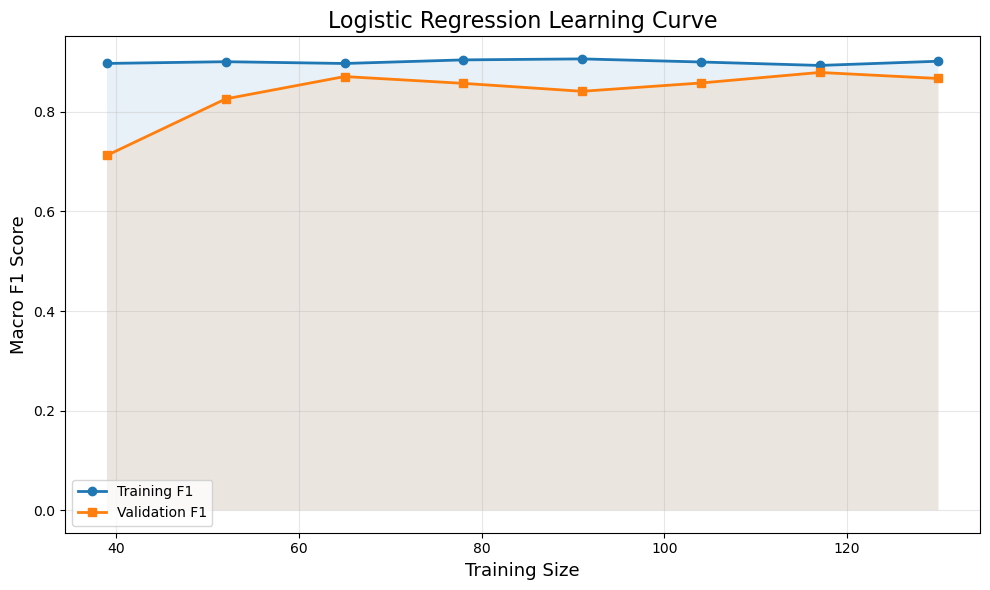

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", multi_class="multinomial"))
])

train_sizes, train_scores, val_scores = learning_curve(
    model_lr,
    df[X_cols],
    df["sustainability_class"],
    cv=5,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, marker="o", linewidth=2, label="Training F1")
plt.plot(train_sizes, val_mean, marker="s", linewidth=2, label="Validation F1")
plt.fill_between(train_sizes, train_mean, alpha=0.1)
plt.fill_between(train_sizes, val_mean, alpha=0.1)

plt.title("Logistic Regression Learning Curve", fontsize=16)
plt.xlabel("Training Size", fontsize=13)
plt.ylabel("Macro F1 Score", fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

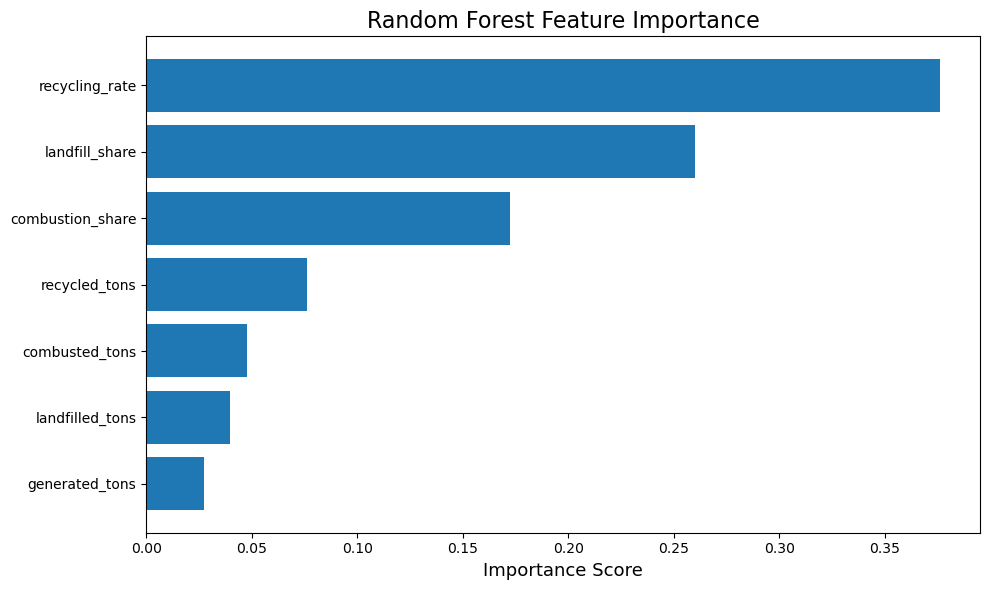

In [6]:
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

rf.fit(df[X_cols], df["sustainability_class"])

importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), np.array(X_cols)[indices])
plt.title("Random Forest Feature Importance", fontsize=16)
plt.xlabel("Importance Score", fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.base import clone

sns.set_theme(style="white")
plt.rcParams["font.family"] = "DejaVu Sans"

def plot_two_confusions_fit(model1, model2, X_train, y_train, X_test, y_test, name1, name2):
    # clone so we don't modify your original objects
    m1 = clone(model1).fit(X_train, y_train)
    m2 = clone(model2).fit(X_train, y_train)

    labels = ["Harmful","Moderate","Sustainable"]
    p1 = m1.predict(X_test)
    p2 = m2.predict(X_test)

    cm1 = confusion_matrix(y_test, p1, labels=labels)
    cm2 = confusion_matrix(y_test, p2, labels=labels)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels,
                ax=axes[0], cbar=False)
    axes[0].set_title(name1, fontsize=15)
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    sns.heatmap(cm2, annot=True, fmt="d", cmap="Purples",
                xticklabels=labels, yticklabels=labels,
                ax=axes[1], cbar=False)
    axes[1].set_title(name2, fontsize=15)
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

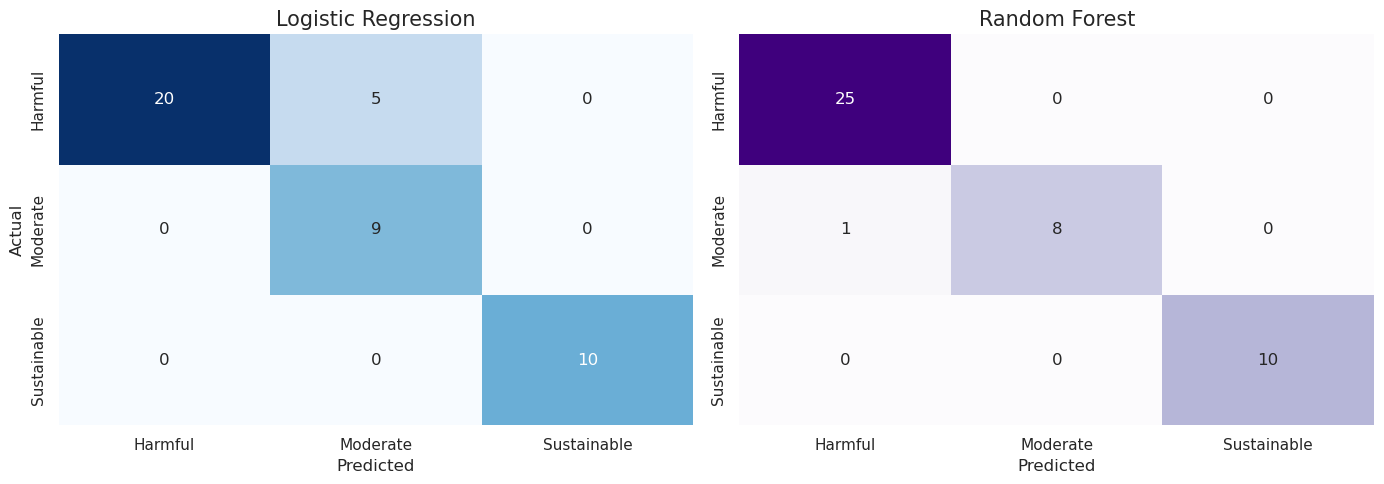

In [13]:
plot_two_confusions_fit(
    model_lr, model_rf,
    Xa_train, ya_train,
    Xa_test, ya_test,
    "Logistic Regression", "Random Forest"
)

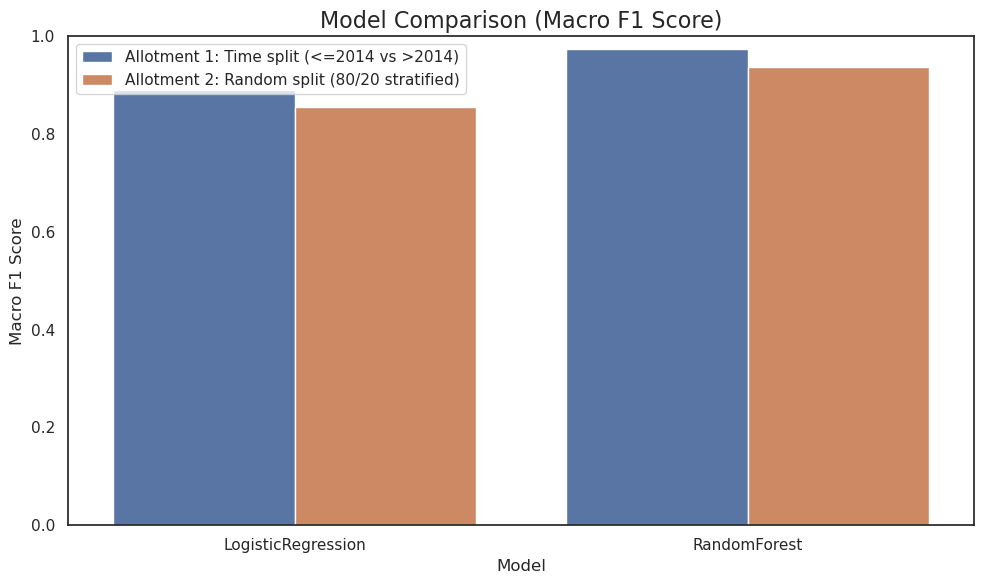

In [11]:
metrics = results_df.copy()

plt.figure(figsize=(10,6))
sns.barplot(data=metrics,
            x="Model",
            y="F1 (macro)",
            hue="Split",
            palette=["#4C72B0", "#DD8452"])

plt.title("Model Comparison (Macro F1 Score)", fontsize=16)
plt.ylabel("Macro F1 Score")
plt.ylim(0,1)
plt.legend(title="")
plt.tight_layout()
plt.show()

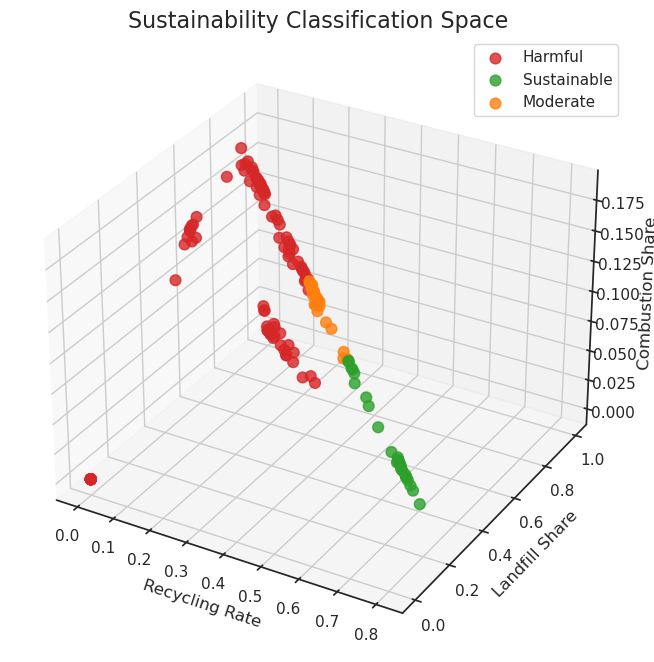

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.ensemble import RandomForestClassifier

# Fit model first
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(df[X_cols], df["sustainability_class"])

# Use only 3 key features for 3D plot
X_plot = df[["recycling_rate", "landfill_share", "combustion_share"]]
y_plot = df["sustainability_class"]

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

colors = {
    "Harmful": "#d62728",
    "Moderate": "#ff7f0e",
    "Sustainable": "#2ca02c"
}

for cls in y_plot.unique():
    mask = y_plot == cls
    ax.scatter(
        X_plot.loc[mask, "recycling_rate"],
        X_plot.loc[mask, "landfill_share"],
        X_plot.loc[mask, "combustion_share"],
        label=cls,
        alpha=0.8,
        color=colors[cls],
        s=60
    )

ax.set_xlabel("Recycling Rate")
ax.set_ylabel("Landfill Share")
ax.set_zlabel("Combustion Share")
ax.set_title("Sustainability Classification Space", fontsize=16)
ax.legend()
plt.show()

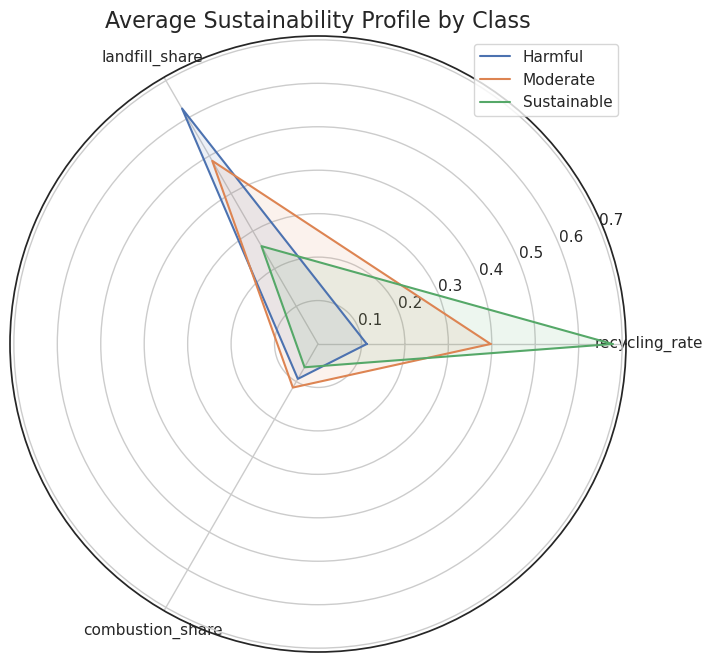

In [16]:
import numpy as np
import matplotlib.pyplot as plt

features = ["recycling_rate","landfill_share","combustion_share"]

class_means = df.groupby("sustainability_class")[features].mean()

angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

for cls in class_means.index:
    values = class_means.loc[cls].tolist()
    values += values[:1]
    ax.plot(angles, values, label=cls)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)
plt.title("Average Sustainability Profile by Class", size=16)
plt.legend()
plt.show()